### 4.1 Objetivo

**4.1 Objetivo**

En esta etapa se entrenan modelos de clasificación para estimar la Probabilidad de Incumplimiento (Probability of Default, PD), utilizando tanto el conjunto de datos real como el conjunto de datos sintético generado mediante Gaussian Copula.

Posteriormente se comparan ambos modelos utilizando métricas de clasificación ampliamente utilizadas en Credit Scoring, con el objetivo de evaluar si los datos sintéticos conservan suficiente información para entrenar modelos predictivos con un desempeño similar al obtenido utilizando datos reales.

### 4.2 Carga de datasets

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df_real = pd.read_parquet("/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/02_Data_Preparation/dataset_real_final.parquet")

df_sintetico = pd.read_csv("/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/03_Syntetic_Data/home_credit_synthetic_gc.csv")

Mounted at /content/drive


In [ ]:
print(df_real.shape)
print(df_sintetico.shape)

(307507, 41)
(307507, 41)


#### 4.2.1 Revisión rápida

In [ ]:
df_real.columns

Index(['TARGET', 'SK_ID_CURR', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
       'AMT_GOODS_PRICE', 'AMT_REQ_CREDIT_BUREAU_YEAR',
       'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
       'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'CODE_GENDER',
       'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_FAMILY_STATUS',
       'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE', 'DAYS_EMPLOYED',
       'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
       'FLAG_OWN_CAR', 'OWN_CAR_AGE', 'FLAG_OWN_REALTY', 'NAME_CONTRACT_TYPE',
       'NAME_TYPE_SUITE', 'WEEKDAY_APPR_PROCESS_START',
       'HOUR_APPR_PROCESS_START', 'AGE', 'EMPLOYMENT_YEARS', 'HAS_CAR_AGE',
       'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO',
       'INCOME_PER_FAMILY', 'CHILDREN_RATIO', 'CREDIT_TERM_EST'],
      dtype='object')

In [ ]:
df_sintetico.columns

Index(['TARGET', 'SK_ID_CURR', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
       'AMT_GOODS_PRICE', 'AMT_REQ_CREDIT_BUREAU_YEAR',
       'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
       'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'CODE_GENDER',
       'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_FAMILY_STATUS',
       'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE', 'DAYS_EMPLOYED',
       'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
       'FLAG_OWN_CAR', 'OWN_CAR_AGE', 'FLAG_OWN_REALTY', 'NAME_CONTRACT_TYPE',
       'NAME_TYPE_SUITE', 'WEEKDAY_APPR_PROCESS_START',
       'HOUR_APPR_PROCESS_START', 'AGE', 'EMPLOYMENT_YEARS', 'HAS_CAR_AGE',
       'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO',
       'INCOME_PER_FAMILY', 'CHILDREN_RATIO', 'CREDIT_TERM_EST'],
      dtype='object')

In [ ]:
#Nulos
df_real.isnull().sum().sum()

np.int64(0)

In [ ]:
df_sintetico.isnull().sum().sum()

np.int64(0)

In [ ]:
#TARGET
df_real["TARGET"].value_counts(normalize=True)

,proportion
TARGET,
0,0.91927
1,0.08073


In [ ]:
df_sintetico["TARGET"].value_counts(normalize=True)

,proportion
TARGET,
0,0.918594
1,0.081406


### 4.3 Preparación de variables

#### 4.3.1 Eliminación de variables no predictoras

In [ ]:
variables_eliminar = [
    "SK_ID_CURR"
]

df_real = df_real.drop(columns=variables_eliminar, errors="ignore")
df_sintetico = df_sintetico.drop(columns=variables_eliminar, errors="ignore")

In [ ]:
print(df_real.shape)
print(df_sintetico.shape)

(307507, 40)
(307507, 40)


#### 4.3.2 Definición de X e y

In [ ]:
#Se separa la variable objetivo (TARGET) de las variables predictoras para ambos conjuntos de datos.
X_real = df_real.drop(columns="TARGET")
y_real = df_real["TARGET"]

X_synth = df_sintetico.drop(columns="TARGET")
y_synth = df_sintetico["TARGET"]

In [ ]:
print(X_real.shape)
print(y_real.shape)

print(X_synth.shape)
print(y_synth.shape)

(307507, 39)
(307507,)
(307507, 39)
(307507,)


#### 4.3.3 Revisión de tipos de variables

In [ ]:
categoricas = X_real.select_dtypes(include=["object", "category"]).columns.tolist()
numericas = X_real.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Variables numéricas:", len(numericas))
print("Variables categóricas:", len(categoricas))

Variables numéricas: 27
Variables categóricas: 12


In [ ]:
categoricas

['CODE_GENDER',
 'NAME_FAMILY_STATUS',
 'NAME_EDUCATION_TYPE',
 'NAME_HOUSING_TYPE',
 'NAME_INCOME_TYPE',
 'OCCUPATION_TYPE',
 'ORGANIZATION_TYPE',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_CONTRACT_TYPE',
 'NAME_TYPE_SUITE',
 'WEEKDAY_APPR_PROCESS_START']

#### 4.3.4 División Train/Test

**Objetivo**

Se divide cada conjunto de datos (real y sintético) en subconjuntos de entrenamiento y prueba utilizando una estrategia estratificada respecto a la variable objetivo (TARGET). Esto garantiza que ambas particiones mantengan la misma proporción de clientes con y sin incumplimiento, permitiendo una evaluación más representativa del desempeño de los modelos.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
#Division del dataset
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real,
    y_real,
    test_size=0.20,
    stratify=y_real,
    random_state=42
)

In [ ]:
#Division del dataset sintetico
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_synth,
    y_synth,
    test_size=0.20,
    stratify=y_synth,
    random_state=42
)

In [ ]:
#Verificacion de dimensiones
print("=== Dataset Real ===")
print("Train:", X_train_real.shape)
print("Test :", X_test_real.shape)

print()

print("=== Dataset Sintético ===")
print("Train:", X_train_syn.shape)
print("Test :", X_test_syn.shape)

=== Dataset Real ===
Train: (246005, 39)
Test : (61502, 39)

=== Dataset Sintético ===
Train: (246005, 39)
Test : (61502, 39)


In [ ]:
#Verificacion del balance de TARGET
print("Distribución TARGET - Real Train")
print(y_train_real.value_counts(normalize=True))

print("\nDistribución TARGET - Real Test")
print(y_test_real.value_counts(normalize=True))

print("\nDistribución TARGET - Sintético Train")
print(y_train_syn.value_counts(normalize=True))

print("\nDistribución TARGET - Sintético Test")
print(y_test_syn.value_counts(normalize=True))

Distribución TARGET - Real Train
TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64

Distribución TARGET - Real Test
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Distribución TARGET - Sintético Train
TARGET
0    0.918595
1    0.081405
Name: proportion, dtype: float64

Distribución TARGET - Sintético Test
TARGET
0    0.918588
1    0.081412
Name: proportion, dtype: float64


#### 4.3.5 One-Hot Encoding

**Objetivo**

En esta etapa se transforman las variables categóricas a una representación numérica mediante One-Hot Encoding. El codificador se ajusta únicamente con los datos de entrenamiento para evitar fuga de información (data leakage) y posteriormente se aplica sobre los conjuntos de prueba y sobre el dataset sintético.

In [ ]:
#Importar librerias
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
#Identificar variables categoricas
cat_features = X_train_real.select_dtypes(
    include=["object", "category"]
).columns.tolist()

cat_features

['CODE_GENDER',
 'NAME_FAMILY_STATUS',
 'NAME_EDUCATION_TYPE',
 'NAME_HOUSING_TYPE',
 'NAME_INCOME_TYPE',
 'OCCUPATION_TYPE',
 'ORGANIZATION_TYPE',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_CONTRACT_TYPE',
 'NAME_TYPE_SUITE',
 'WEEKDAY_APPR_PROCESS_START']

In [ ]:
#Identificar variables numericas
num_features = X_train_real.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

len(num_features), len(cat_features)

(27, 12)

In [ ]:
#Crear el encoder
encoder = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            cat_features
        )
    ],
    remainder="passthrough"
)

In [ ]:
print("Categóricas:")
print(cat_features)

print("\nNuméricas:")
print(num_features)

Categóricas:
['CODE_GENDER', 'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_CONTRACT_TYPE', 'NAME_TYPE_SUITE', 'WEEKDAY_APPR_PROCESS_START']

Numéricas:
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'DAYS_EMPLOYED', 'OWN_CAR_AGE', 'HOUR_APPR_PROCESS_START', 'AGE', 'EMPLOYMENT_YEARS', 'HAS_CAR_AGE', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'INCOME_PER_FAMILY', 'CHILDREN_RATIO', 'CREDIT_TERM_EST']


In [ ]:
#Ajustar unicamente con el entranmiento real
encoder.fit(X_train_real)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['CODE_GENDER', 'NAME_FAMILY_STATUS',
                                  'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE',
                                  'NAME_INCOME_TYPE', 'OCCUPATION_TYPE',
                                  'ORGANIZATION_TYPE', 'FLAG_OWN_CAR',
                                  'FLAG_OWN_REALTY', 'NAME_CONTRACT_TYPE',
                                  'NAME_TYPE_SUITE',
                                  'WEEKDAY_APPR_PROCESS_START'])])

In [ ]:
#Verificar cuantas variables genera
feature_names = encoder.get_feature_names_out()

print("Número de variables originales:", X_train_real.shape[1])
print("Número de variables después del encoding:", len(feature_names))

Número de variables originales: 39
Número de variables después del encoding: 150


In [ ]:
#Muestra de variables generadas:
feature_names[:20]

array(['categorical__CODE_GENDER_F', 'categorical__CODE_GENDER_M',
       'categorical__NAME_FAMILY_STATUS_Civil marriage',
       'categorical__NAME_FAMILY_STATUS_Married',
       'categorical__NAME_FAMILY_STATUS_Separated',
       'categorical__NAME_FAMILY_STATUS_Single / not married',
       'categorical__NAME_FAMILY_STATUS_Unknown',
       'categorical__NAME_FAMILY_STATUS_Widow',
       'categorical__NAME_EDUCATION_TYPE_Academic degree',
       'categorical__NAME_EDUCATION_TYPE_Higher education',
       'categorical__NAME_EDUCATION_TYPE_Incomplete higher',
       'categorical__NAME_EDUCATION_TYPE_Lower secondary',
       'categorical__NAME_EDUCATION_TYPE_Secondary / secondary special',
       'categorical__NAME_HOUSING_TYPE_Co-op apartment',
       'categorical__NAME_HOUSING_TYPE_House / apartment',
       'categorical__NAME_HOUSING_TYPE_Municipal apartment',
       'categorical__NAME_HOUSING_TYPE_Office apartment',
       'categorical__NAME_HOUSING_TYPE_Rented apartment',
       '

In [ ]:
# Transformar los conjuntos de entrenamiento y prueba

X_train_real_enc = encoder.transform(X_train_real)
X_test_real_enc = encoder.transform(X_test_real)

X_train_syn_enc = encoder.transform(X_train_syn)
X_test_syn_enc = encoder.transform(X_test_syn)

In [ ]:
#Verificar dimensiones
print("X_train_real_enc:", X_train_real_enc.shape)
print("X_test_real_enc :", X_test_real_enc.shape)

print("X_train_syn_enc :", X_train_syn_enc.shape)
print("X_test_syn_enc  :", X_test_syn_enc.shape)

X_train_real_enc: (246005, 150)
X_test_real_enc : (61502, 150)
X_train_syn_enc : (246005, 150)
X_test_syn_enc  : (61502, 150)


#### 4.3.6 Alineación de columnas

Aunque los tamaños coincidan, conviene hacer una comprobación explícita de que las columnas y su orden son idénticos.

In [ ]:
# ============================================================
# 6.3.5 Alineación de columnas
# ============================================================

# Obtener nombres de las variables generadas por el encoder
feature_names = encoder.get_feature_names_out()

print("Número de variables generadas:", len(feature_names))

# Verificar dimensiones
print("\nDimensiones:")
print("X_train_real_enc:", X_train_real_enc.shape)
print("X_test_real_enc :", X_test_real_enc.shape)
print("X_train_syn_enc :", X_train_syn_enc.shape)
print("X_test_syn_enc  :", X_test_syn_enc.shape)

# Verificar que todos tienen las mismas variables
assert X_train_real_enc.shape[1] == len(feature_names)
assert X_test_real_enc.shape[1] == len(feature_names)
assert X_train_syn_enc.shape[1] == len(feature_names)
assert X_test_syn_enc.shape[1] == len(feature_names)

print("\n✓ Los cuatro conjuntos tienen exactamente las mismas 150 variables.")

Número de variables generadas: 150

Dimensiones:
X_train_real_enc: (246005, 150)
X_test_real_enc : (61502, 150)
X_train_syn_enc : (246005, 150)
X_test_syn_enc  : (61502, 150)

✓ Los cuatro conjuntos tienen exactamente las mismas 150 variables.


#### 4.3.7 Escalado (solo cuando aplique)

| Modelo              | ¿Escalado? | Motivo                                   |
| ------------------- | ---------- | ---------------------------------------- |
| Logistic Regression | ✅ Sí       | Es sensible a la escala de las variables |
| Random Forest       | ❌ No       | Basado en árboles                        |
| XGBoost             | ❌ No       | Basado en árboles                        |
| LightGBM            | ❌ No       | Basado en árboles                        |


##### 4.3.7.1 Escalado para Logistic Regression

In [ ]:
#Ajuste a Train de los datos reales
from sklearn.preprocessing import StandardScaler

# Crear scaler para los datos reales
scaler_real = StandardScaler()

# Ajustar SOLO con Train
X_train_real_scaled = scaler_real.fit_transform(X_train_real_enc)

# Transformar Test usando el scaler aprendido en Train
X_test_real_scaled = scaler_real.transform(X_test_real_enc)

print("X_train_real_scaled:", X_train_real_scaled.shape)
print("X_test_real_scaled :", X_test_real_scaled.shape)

X_train_real_scaled: (246005, 150)
X_test_real_scaled : (61502, 150)


In [ ]:
#Ajuste a Train para los datos sinteticos
# Crear scaler para los datos sintéticos
scaler_syn = StandardScaler()

# Ajustar SOLO con Train sintético
X_train_syn_scaled = scaler_syn.fit_transform(X_train_syn_enc)

# Transformar Test sintético
X_test_syn_scaled = scaler_syn.transform(X_test_syn_enc)

print("X_train_syn_scaled:", X_train_syn_scaled.shape)
print("X_test_syn_scaled :", X_test_syn_scaled.shape)

X_train_syn_scaled: (246005, 150)
X_test_syn_scaled : (61502, 150)


##### 4.3.7.2 ¿Qué hacemos con Random Forest, XGBoost y LightGBM?

In [ ]:
#Conservamos las variables sin escalar
X_train_real_enc
X_test_real_enc

X_train_syn_enc
X_test_syn_enc

array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.32015062e+05, 3.78740296e-01, 2.51580688e+01],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
        6.76984708e+04, 4.17964920e-01, 1.26794251e+01],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        7.68407736e+04, 3.88214340e-01, 1.79328783e+01],
       ...,
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        7.51968834e+04, 4.18775410e-01, 1.30604519e+01],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        6.40864186e+04, 4.57592922e-01, 1.29913922e+01],
       [1.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        4.36801189e+04, 4.51368689e-01, 1.45497372e+01]])

In [ ]:
#Comparacion final
print("REAL")
print("Train:", X_train_real_scaled.shape)
print("Test :", X_test_real_scaled.shape)

print("\nSINTÉTICO")
print("Train:", X_train_syn_scaled.shape)
print("Test :", X_test_syn_scaled.shape)

REAL
Train: (246005, 150)
Test : (61502, 150)

SINTÉTICO
Train: (246005, 150)
Test : (61502, 150)


### 4.4 Entrenamiento del modelo con datos reales

Vamos a entrenar cuatro modelos:

Logistic Regression
Random Forest
XGBoost
LightGBM

La idea metodológica será mantener los mismos conjuntos Train/Test y el mismo TARGET para los cuatro modelos, de modo que la comparación posterior sea justa.

#### 4.4.1 Logistic Regression

In [ ]:
#Usaremos las variables escaladas
X_train_real_scaled
X_test_real_scaled
y_train_real
y_test_real

,TARGET
180592,0
186421,0
103497,0
133150,0
211898,0
...,...
16213,0
294616,0
286391,0
46774,1


In [ ]:
#IMportamos
from sklearn.linear_model import LogisticRegression

In [ ]:
#Creamos y entrenamos el modelo
lr_real = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_real.fit(
    X_train_real_scaled,
    y_train_real
)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
#Comprobamos
print("Logistic Regression entrenada correctamente.")

Logistic Regression entrenada correctamente.


#### 4.4.2 Random Forest

He incluido class_weight="balanced" porque tu variable TARGET está bastante desbalanceada. Esto es especialmente importante en un problema de PD/default, donde la clase minoritaria es precisamente la que nos interesa detectar.

In [ ]:
#Aqui no necesitamso escalado
from sklearn.ensemble import RandomForestClassifier

rf_real = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_real.fit(
    X_train_real_enc,
    y_train_real
)

print("Random Forest entrenado correctamente.")

Random Forest entrenado correctamente.


#### 4.4.3 XGBoost

In [ ]:
#Instalamos la libreria
!pip install xgboost -q

In [ ]:
#Importamos
from xgboost import XGBClassifier

In [ ]:
#Como target esta desbalanceado podemos calcular  automaticamente la relacion entre clases
scale_pos_weight = (
    (y_train_real == 0).sum() /
    (y_train_real == 1).sum()
)

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 11.386958710976838


In [ ]:
xgb_real = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_real.fit(
    X_train_real_enc,
    y_train_real
)

print("XGBoost entrenado correctamente.")

XGBoost entrenado correctamente.


#### 4.4.4 LightGBM

In [ ]:
#Importamos la libreria
!pip install lightgbm -q

In [ ]:
#Importamos
from lightgbm import LGBMClassifier

In [ ]:
#Entrenamos
lgbm_real = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_real.fit(
    X_train_real_enc,
    y_train_real
)

print("LightGBM entrenado correctamente.")

LightGBM entrenado correctamente.


#### 4.4.5 Comprobación de los cuatro modelos

In [ ]:
#Comprobamos los modelos
modelos_reales = {
    "Logistic Regression": lr_real,
    "Random Forest": rf_real,
    "XGBoost": xgb_real,
    "LightGBM": lgbm_real
}

for nombre, modelo in modelos_reales.items():
    print(f"{nombre}: entrenado")

Logistic Regression: entrenado
Random Forest: entrenado
XGBoost: entrenado
LightGBM: entrenado


### 4.5 Evaluación del modelo real

#### 4.5.1 Predicciones

In [ ]:
#Logistic Regression
y_pred_lr_real = lr_real.predict(X_test_real_scaled)
y_prob_lr_real = lr_real.predict_proba(X_test_real_scaled)[:, 1]

In [ ]:
#Random Forest
y_pred_rf_real = rf_real.predict(X_test_real_enc)
y_prob_rf_real = rf_real.predict_proba(X_test_real_enc)[:, 1]

In [ ]:
#XGBoost
y_pred_xgb_real = xgb_real.predict(X_test_real_enc)
y_prob_xgb_real = xgb_real.predict_proba(X_test_real_enc)[:, 1]

In [ ]:
#LightGBM
y_pred_lgbm_real = lgbm_real.predict(X_test_real_enc)
y_prob_lgbm_real = lgbm_real.predict_proba(X_test_real_enc)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Aquí tenemos dos tipos de resultado:

y_pred_* → clasificación final 0/1.
y_prob_* → probabilidad estimada de TARGET = 1.

Para nuestro TFM, las probabilidades son especialmente importantes porque estamos trabajando con estimación de PD, no solamente con clasificación.

#### 4.5.2–4.5.6 Métricas

In [ ]:
#Calcular metricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

resultados_reales = []

modelos_predicciones = {
    "Logistic Regression": (y_pred_lr_real, y_prob_lr_real),
    "Random Forest": (y_pred_rf_real, y_prob_rf_real),
    "XGBoost": (y_pred_xgb_real, y_prob_xgb_real),
    "LightGBM": (y_pred_lgbm_real, y_prob_lgbm_real)
}

for nombre, (y_pred, y_prob) in modelos_predicciones.items():

    resultados_reales.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test_real, y_pred),
        "Precision": precision_score(
            y_test_real,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_real,
            y_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test_real,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test_real,
            y_prob
        )
    })

In [ ]:
#Convertimos los resultado en un dataframe
import pandas as pd

df_resultados_reales = pd.DataFrame(resultados_reales)

df_resultados_reales

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.919417,0.538462,0.012689,0.024793,0.743689
1,Random Forest,0.912913,0.370787,0.112991,0.173202,0.751758
2,XGBoost,0.716302,0.173954,0.670695,0.276257,0.763645
3,LightGBM,0.709505,0.172613,0.684995,0.275742,0.765963


#### 4.5.7 Interpretación

Cuando tengas la tabla, no vamos a elegir automáticamente el modelo que tenga mayor Accuracy.

Para el problema de PD, prestaremos especial atención a:

Recall

Nos indica qué proporción de los verdaderos casos TARGET = 1 conseguimos detectar.

Un Recall bajo significa que el modelo está dejando pasar muchos casos de incumplimiento.

Precision

Nos indica qué proporción de los casos que el modelo identifica como TARGET = 1 realmente pertenecen a esa clase.

F1-score

Combina Precision y Recall y será útil cuando queramos equilibrar ambas métricas.

ROC-AUC

Será una de las métricas más importantes para nuestro TFM.

Evalúa la capacidad del modelo para ordenar correctamente a los clientes según su riesgo, independientemente de un umbral concreto de clasificación.

Esto es particularmente relevante para nuestro objetivo de estimar PD.

Accuracy

La conservaremos porque forma parte de la evaluación solicitada, pero no debería ser nuestra principal métrica de selección, debido al desbalance de TARGET.

#### 4.5.8 Matrices de confusión

In [ ]:
#Importamos
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
for nombre, (y_pred, y_prob) in modelos_predicciones.items():

    cm = confusion_matrix(y_test_real, y_pred)

    print(f"\n{nombre}")
    print(cm)


Logistic Regression
[[56483    54]
 [ 4902    63]]

Random Forest
[[55585   952]
 [ 4404   561]]

XGBoost
[[40724 15813]
 [ 1635  3330]]

LightGBM
[[40235 16302]
 [ 1564  3401]]


### 4.6: Entrenamiento del modelo con datos sintéticos.

La idea metodológica es importante: no vamos a optimizar todavía. Primero obtenemos el rendimiento base de los modelos sintéticos. Después hacemos la optimización de hiperparámetros de forma controlada y, finalmente, comparamos los modelos optimizados reales vs. sintéticos.

#### 4.6.1 Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_syn = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_syn.fit(X_train_syn_enc, y_train_syn)

y_pred_lr_syn = lr_syn.predict(X_test_syn_enc)
y_prob_lr_syn = lr_syn.predict_proba(X_test_syn_enc)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### 4.6.2 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_syn = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_syn.fit(X_train_syn_enc, y_train_syn)

y_pred_rf_syn = rf_syn.predict(X_test_syn_enc)
y_prob_rf_syn = rf_syn.predict_proba(X_test_syn_enc)[:, 1]

#### 4.6.3 XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_syn = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_syn.fit(X_train_syn_enc, y_train_syn)

y_pred_xgb_syn = xgb_syn.predict(X_test_syn_enc)
y_prob_xgb_syn = xgb_syn.predict_proba(X_test_syn_enc)[:, 1]

#### 4.6.4 LightGBM

In [ ]:
from lightgbm import LGBMClassifier

lgbm_syn = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_syn.fit(X_train_syn_enc, y_train_syn)

y_pred_lgbm_syn = lgbm_syn.predict(X_test_syn_enc)
y_prob_lgbm_syn = lgbm_syn.predict_proba(X_test_syn_enc)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### 4.6.5 Comprobación

In [ ]:
modelos_sinteticos = {
    "Logistic Regression": lr_syn,
    "Random Forest": rf_syn,
    "XGBoost": xgb_syn,
    "LightGBM": lgbm_syn
}

for nombre, modelo in modelos_sinteticos.items():
    print(f"{nombre}: entrenado correctamente")

Logistic Regression: entrenado correctamente
Random Forest: entrenado correctamente
XGBoost: entrenado correctamente
LightGBM: entrenado correctamente


### 4.7 Evaluación del modelo sintético

In [ ]:
#Evaluar los 4 modelos sinteticos sobre la data real
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

modelos_syn = {
    "Logistic Regression": lr_syn,
    "Random Forest": rf_syn,
    "XGBoost": xgb_syn,
    "LightGBM": lgbm_syn
}

resultados_syn = []

matrices_confusion_syn = {}

for nombre, modelo in modelos_syn.items():

    # Predicciones sobre TEST REAL
    y_pred = modelo.predict(X_test_real_enc)
    y_prob = modelo.predict_proba(X_test_real_enc)[:, 1]

    resultados_syn.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test_real, y_pred),
        "Precision": precision_score(y_test_real, y_pred, zero_division=0),
        "Recall": recall_score(y_test_real, y_pred, zero_division=0),
        "F1-score": f1_score(y_test_real, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_real, y_prob)
    })

    matrices_confusion_syn[nombre] = confusion_matrix(
        y_test_real,
        y_pred
    )

resultados_syn = pd.DataFrame(resultados_syn)

resultados_syn

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.919271,0.0,0.0,0.0,0.584078
1,Random Forest,0.919271,0.0,0.0,0.0,0.612540
2,XGBoost,0.919255,0.0,0.0,0.0,0.707478
3,LightGBM,0.919271,0.0,0.0,0.0,0.710671


In [ ]:
#Mostrar las matrices de confusion
for nombre, matriz in matrices_confusion_syn.items():

    print(f"\n{nombre}")
    print(matriz)


Logistic Regression
[[56537     0]
 [ 4965     0]]

Random Forest
[[56537     0]
 [ 4965     0]]

XGBoost
[[56536     1]
 [ 4965     0]]

LightGBM
[[56537     0]
 [ 4965     0]]


### NOTA: Evaluacion del datos sinteticos Gaussian copula

In [ ]:
# Dataset sintético seleccionado
df_model_synth = df_sintetico.copy()

print("Dimensiones dataset sintético:")
print(df_model_synth.shape)

print("\nDistribución de TARGET:")
print(df_model_synth["TARGET"].value_counts())

print("\nProporción de TARGET:")
print(df_model_synth["TARGET"].value_counts(normalize=True))

Dimensiones dataset sintético:
(307507, 40)

Distribución de TARGET:
TARGET
0    282474
1     25033
Name: count, dtype: int64

Proporción de TARGET:
TARGET
0    0.918594
1    0.081406
Name: proportion, dtype: float64


In [ ]:
#Comprobacion antes de entreanr el modelo
print(df_model_synth["TARGET"].value_counts(normalize=True))

TARGET
0    0.918594
1    0.081406
Name: proportion, dtype: float64


In [ ]:
#Division propia del dataset sintetico
#Usaremos estratificación para mantener ese 8.14% de TARGET=1 tanto en train como en test:
from sklearn.model_selection import train_test_split

X_synth = df_model_synth.drop(columns=["TARGET"])
y_synth = df_model_synth["TARGET"]

X_train_synth, X_test_synth, y_train_synth, y_test_synth = train_test_split(
    X_synth,
    y_synth,
    test_size=0.20,
    stratify=y_synth,
    random_state=42
)

print("X_train_synth:", X_train_synth.shape)
print("X_test_synth :", X_test_synth.shape)

print("\nDistribución TARGET - Train:")
print(y_train_synth.value_counts(normalize=True))

print("\nDistribución TARGET - Test:")
print(y_test_synth.value_counts(normalize=True))

X_train_synth: (246005, 39)
X_test_synth : (61502, 39)

Distribución TARGET - Train:
TARGET
0    0.918595
1    0.081405
Name: proportion, dtype: float64

Distribución TARGET - Test:
TARGET
0    0.918588
1    0.081412
Name: proportion, dtype: float64


#### Volvemos al paso: 6.6 Entrenamiento de modelos con datos sintéticos.

In [ ]:
#6.3.4 — One-Hot Encoding del conjunto sintético
categorical_cols_synth = X_train_synth.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols_synth = X_train_synth.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

print("Variables categóricas:")
print(categorical_cols_synth)

print("\nNúmero de variables categóricas:", len(categorical_cols_synth))
print("Número de variables numéricas:", len(numeric_cols_synth))

Variables categóricas:
['CODE_GENDER', 'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_CONTRACT_TYPE', 'NAME_TYPE_SUITE', 'WEEKDAY_APPR_PROCESS_START']

Número de variables categóricas: 12
Número de variables numéricas: 27


In [ ]:
#Creamos el encoder
from sklearn.preprocessing import OneHotEncoder

encoder_synth = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_synth_cat = encoder_synth.fit_transform(
    X_train_synth[categorical_cols_synth]
)

X_test_synth_cat = encoder_synth.transform(
    X_test_synth[categorical_cols_synth]
)

In [ ]:
#Convertimos el dataframe
encoded_cols_synth = encoder_synth.get_feature_names_out(
    categorical_cols_synth
)

X_train_synth_cat = pd.DataFrame(
    X_train_synth_cat,
    columns=encoded_cols_synth,
    index=X_train_synth.index
)

X_test_synth_cat = pd.DataFrame(
    X_test_synth_cat,
    columns=encoded_cols_synth,
    index=X_test_synth.index
)

In [ ]:
#Añadimos las variables numericas
X_train_synth_enc = pd.concat(
    [
        X_train_synth[numeric_cols_synth],
        X_train_synth_cat
    ],
    axis=1
)

X_test_synth_enc = pd.concat(
    [
        X_test_synth[numeric_cols_synth],
        X_test_synth_cat
    ],
    axis=1
)

In [ ]:
print("X_train_synth_enc:", X_train_synth_enc.shape)
print("X_test_synth_enc :", X_test_synth_enc.shape)

X_train_synth_enc: (246005, 149)
X_test_synth_enc : (61502, 149)


In [ ]:
#Comprobacion
print(
    "¿Mismas columnas Train/Test?:",
    list(X_train_synth_enc.columns) == list(X_test_synth_enc.columns)
)

print(
    "¿Hay NaN en Train?:",
    X_train_synth_enc.isna().sum().sum()
)

print(
    "¿Hay NaN en Test?:",
    X_test_synth_enc.isna().sum().sum()
)

¿Mismas columnas Train/Test?: True
¿Hay NaN en Train?: 0
¿Hay NaN en Test?: 0


In [ ]:
#UTilizaremos
X_train_synth_enc
y_train_synth

,TARGET
223707,0
26586,0
14748,0
60284,1
127487,0
...,...
257303,0
261207,0
167441,0
300055,0


In [ ]:
#Y para evaluar
X_test_synth_enc
y_test_synth

,TARGET
241496,0
10910,0
173589,0
235927,0
27867,0
...,...
147538,0
35231,0
181756,0
274762,0


In [ ]:
#Se tiene que escalar el dataset para el logistic regresion
from sklearn.preprocessing import StandardScaler

scaler_synth = StandardScaler()

X_train_synth_scaled = scaler_synth.fit_transform(X_train_synth_enc)
X_test_synth_scaled = scaler_synth.transform(X_test_synth_enc)

In [ ]:
#Logistic regresion con X_train_synth_scaled
from sklearn.linear_model import LogisticRegression
import time

inicio = time.time()

lr_synth = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_synth.fit(X_train_synth_scaled, y_train_synth)

tiempo_lr_synth = time.time() - inicio

print(f"Tiempo entrenamiento Logistic Regression: {tiempo_lr_synth:.2f} segundos")

Tiempo entrenamiento Logistic Regression: 4.18 segundos


In [ ]:
#Random forest
from sklearn.ensemble import RandomForestClassifier

inicio = time.time()

rf_synth = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_synth.fit(X_train_synth_enc, y_train_synth)

tiempo_rf_synth = time.time() - inicio

print(f"Tiempo entrenamiento Random Forest: {tiempo_rf_synth:.2f} segundos")

Tiempo entrenamiento Random Forest: 292.60 segundos


In [ ]:
#XGBoost
from xgboost import XGBClassifier

inicio = time.time()

xgb_synth = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_synth.fit(X_train_synth_enc, y_train_synth)

tiempo_xgb_synth = time.time() - inicio

print(f"Tiempo entrenamiento XGBoost: {tiempo_xgb_synth:.2f} segundos")

Tiempo entrenamiento XGBoost: 19.79 segundos


In [ ]:
# Obtener los nombres reales de las variables generadas por el encoder

#feature_names_synth = encoder.get_feature_names_out()

#print("Número de variables en X_train_synth_enc:", X_train_synth_enc.shape[1])
#print("Número de nombres generados por encoder:", len(feature_names_synth))

In [ ]:
#Crear los nombres compatibles con LightGBM
#import re

#feature_names_lgbm_safe = [
#    re.sub(r'[^A-Za-z0-9_]+', '_', str(col))
#    for col in feature_names_synth
#]

#print("Número de nombres seguros:", len(feature_names_lgbm_safe))

In [ ]:
#Comprobamos que no hayan duplicados
#print("¿Hay nombres duplicados?:",
#      len(feature_names_lgbm_safe) != len(set(feature_names_lgbm_safe)))

In [ ]:
#Comprobacion definitiva
#assert X_train_synth_enc.shape[1] == len(feature_names_lgbm_safe)
#
#print("✓ Número de variables:", X_train_synth_enc.shape[1])
#print("✓ Número de nombres:", len(feature_names_lgbm_safe))
#print("✓ Variables y nombres están alineados")

In [ ]:
#Diagnostico
#print("X_train_synth_enc:", X_train_synth_enc.shape)

#feature_names_synth = encoder.get_feature_names_out()

#print("Feature names del encoder:", len(feature_names_synth))

#print("\nPrimeros 10 nombres:")
#print(feature_names_synth[:10])

#print("\nÚltimos 10 nombres:")
#print(feature_names_synth[-10:])

In [ ]:
#print("X_test_synth_enc:", X_test_synth_enc.shape)

#print("¿Train y Test tienen mismo número de columnas?:",
#      X_train_synth_enc.shape[1] == X_test_synth_enc.shape[1])

In [ ]:
# ============================================================
# RECONSTRUIR ENCODING DEL DATASET SINTÉTICO
# ============================================================

# Transformar nuevamente los datos sintéticos
X_train_synth_enc = encoder.transform(X_train_synth)
X_test_synth_enc = encoder.transform(X_test_synth)

print("X_train_synth_enc:", X_train_synth_enc.shape)
print("X_test_synth_enc :", X_test_synth_enc.shape)

# Obtener nombres de variables
feature_names_synth = encoder.get_feature_names_out()

print("Número de nombres del encoder:", len(feature_names_synth))

X_train_synth_enc: (246005, 150)
X_test_synth_enc : (61502, 150)
Número de nombres del encoder: 150


In [ ]:
#Limpiamos los nombres para LightGBM
import re

feature_names_lgbm_safe = [
    re.sub(r'[^A-Za-z0-9_]+', '_', str(col))
    for col in feature_names_synth
]

print("Número de features:", len(feature_names_lgbm_safe))
print("¿Hay duplicados?:",
      len(feature_names_lgbm_safe) != len(set(feature_names_lgbm_safe)))

Número de features: 150
¿Hay duplicados?: False


In [ ]:
assert X_train_synth_enc.shape[1] == len(feature_names_lgbm_safe)
assert X_test_synth_enc.shape[1] == len(feature_names_lgbm_safe)

print("✓ Train:", X_train_synth_enc.shape)
print("✓ Test :", X_test_synth_enc.shape)
print("✓ Features:", len(feature_names_lgbm_safe))
print("✓ Todo correctamente alineado")

✓ Train: (246005, 150)
✓ Test : (61502, 150)
✓ Features: 150
✓ Todo correctamente alineado


In [ ]:
#LightGBM
from lightgbm import LGBMClassifier
import time

inicio = time.time()

modelo_lgbm_syn = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

modelo_lgbm_syn.fit(
    X_train_synth_enc,
    y_train_synth,
    feature_name=feature_names_lgbm_safe
)

tiempo_lgbm_synth = time.time() - inicio

print(f"Tiempo entrenamiento LightGBM: {tiempo_lgbm_synth:.2f} segundos")

Tiempo entrenamiento LightGBM: 10.53 segundos


In [ ]:
#Mostramos resultado de los modelos
modelos_synth = {
    "Logistic Regression": lr_synth,
    "Random Forest": rf_synth,
    "XGBoost": xgb_synth,
    "LightGBM": modelo_lgbm_syn
}

print("Modelos sintéticos entrenados:")
for nombre in modelos_synth:
    print(f"- {nombre}")

Modelos sintéticos entrenados:
- Logistic Regression
- Random Forest
- XGBoost
- LightGBM


In [ ]:
#Comprobando el estado actual:
print("Train sintético:", X_train_synth_enc.shape)
print("Test sintético :", X_test_synth_enc.shape)

print("TARGET Train:", y_train_synth.shape)
print("TARGET Test :", y_test_synth.shape)

Train sintético: (246005, 150)
Test sintético : (61502, 150)
TARGET Train: (246005,)
TARGET Test : (61502,)


In [ ]:
#Se tiene que escalar el dataset para el logistic regresion (nuevamente con el X_train_synth_enc actualizado)
from sklearn.preprocessing import StandardScaler

scaler_synth = StandardScaler()

X_train_synth_scaled = scaler_synth.fit_transform(X_train_synth_enc)
X_test_synth_scaled = scaler_synth.transform(X_test_synth_enc)

In [ ]:
#Logistic regresion
from sklearn.linear_model import LogisticRegression
import time

inicio = time.time()

modelo_lr_syn = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_lr_syn.fit(
    X_train_synth_scaled,
    y_train_synth
)

tiempo_lr_syn = time.time() - inicio

print(f"Tiempo entrenamiento Logistic Regression: {tiempo_lr_syn:.2f} segundos")

Tiempo entrenamiento Logistic Regression: 1.23 segundos


In [ ]:
#Reentrenamos nuevamentes los modelos
#RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

inicio = time.time()

modelo_rf_syn = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight=None
)

modelo_rf_syn.fit(
    X_train_synth_enc,
    y_train_synth
)

tiempo_rf_syn = time.time() - inicio

print(f"Tiempo entrenamiento Random Forest: {tiempo_rf_syn:.2f} segundos")

Tiempo entrenamiento Random Forest: 346.00 segundos


In [ ]:
#XGBOOST
from xgboost import XGBClassifier

inicio = time.time()

modelo_xgb_syn = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

modelo_xgb_syn.fit(
    X_train_synth_enc,
    y_train_synth
)

tiempo_xgb_syn = time.time() - inicio

print(f"Tiempo entrenamiento XGBoost: {tiempo_xgb_syn:.2f} segundos")

Tiempo entrenamiento XGBoost: 21.40 segundos


In [ ]:
#Ultima validacion antes de evaluar
print("Variables del dataset:", X_train_synth_enc.shape[1])

print("LR :", modelo_lr_syn.n_features_in_)
print("RF :", modelo_rf_syn.n_features_in_)
print("XGB:", modelo_xgb_syn.n_features_in_)
print("LGB:", modelo_lgbm_syn.n_features_in_)

Variables del dataset: 150
LR : 150
RF : 150
XGB: 150
LGB: 150


#### Volvemos al paso: 6.7 Evaluación de los modelos sintéticos

In [ ]:
#Reutilizar los modelos entrenados en 6.6 y calcular las cinco métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

resultados_sinteticos = []

# =========================================================
# 1. Logistic Regression
# =========================================================

y_pred_lr_syn = modelo_lr_syn.predict(X_test_synth_scaled)
y_prob_lr_syn = modelo_lr_syn.predict_proba(X_test_synth_scaled)[:, 1]

resultados_sinteticos.append({
    "Modelo": "Logistic Regression",
    "Accuracy": accuracy_score(y_test_synth, y_pred_lr_syn),
    "Precision": precision_score(y_test_synth, y_pred_lr_syn, zero_division=0),
    "Recall": recall_score(y_test_synth, y_pred_lr_syn, zero_division=0),
    "F1-score": f1_score(y_test_synth, y_pred_lr_syn, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_synth, y_prob_lr_syn)
})


# =========================================================
# 2. Random Forest
# =========================================================

y_pred_rf_syn = modelo_rf_syn.predict(X_test_synth_enc)
y_prob_rf_syn = modelo_rf_syn.predict_proba(X_test_synth_enc)[:, 1]

resultados_sinteticos.append({
    "Modelo": "Random Forest",
    "Accuracy": accuracy_score(y_test_synth, y_pred_rf_syn),
    "Precision": precision_score(y_test_synth, y_pred_rf_syn, zero_division=0),
    "Recall": recall_score(y_test_synth, y_pred_rf_syn, zero_division=0),
    "F1-score": f1_score(y_test_synth, y_pred_rf_syn, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_synth, y_prob_rf_syn)
})


# =========================================================
# 3. XGBoost
# =========================================================

y_pred_xgb_syn = modelo_xgb_syn.predict(X_test_synth_enc)
y_prob_xgb_syn = modelo_xgb_syn.predict_proba(X_test_synth_enc)[:, 1]

resultados_sinteticos.append({
    "Modelo": "XGBoost",
    "Accuracy": accuracy_score(y_test_synth, y_pred_xgb_syn),
    "Precision": precision_score(y_test_synth, y_pred_xgb_syn, zero_division=0),
    "Recall": recall_score(y_test_synth, y_pred_xgb_syn, zero_division=0),
    "F1-score": f1_score(y_test_synth, y_pred_xgb_syn, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_synth, y_prob_xgb_syn)
})


# =========================================================
# 4. LightGBM
# =========================================================

y_pred_lgbm_syn = modelo_lgbm_syn.predict(X_test_synth_enc)
y_prob_lgbm_syn = modelo_lgbm_syn.predict_proba(X_test_synth_enc)[:, 1]

resultados_sinteticos.append({
    "Modelo": "LightGBM",
    "Accuracy": accuracy_score(y_test_synth, y_pred_lgbm_syn),
    "Precision": precision_score(y_test_synth, y_pred_lgbm_syn, zero_division=0),
    "Recall": recall_score(y_test_synth, y_pred_lgbm_syn, zero_division=0),
    "F1-score": f1_score(y_test_synth, y_pred_lgbm_syn, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_synth, y_prob_lgbm_syn)
})


# =========================================================
# Tabla final
# =========================================================

resultados_sinteticos_df = pd.DataFrame(resultados_sinteticos)

resultados_sinteticos_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.918588,0.0,0.0,0.0,0.571613
1,Random Forest,0.918588,0.0,0.0,0.0,0.532055
2,XGBoost,0.918588,0.0,0.0,0.0,0.562513
3,LightGBM,0.918588,0.0,0.0,0.0,0.564916


In [ ]:
#Generamos las matrices de confucion
print("Matrices de confusión - modelos entrenados con datos sintéticos\n")

modelos_syn = {
    "Logistic Regression": y_pred_lr_syn,
    "Random Forest": y_pred_rf_syn,
    "XGBoost": y_pred_xgb_syn,
    "LightGBM": y_pred_lgbm_syn
}

for nombre, predicciones in modelos_syn.items():
    print(nombre)
    print(confusion_matrix(y_test_synth, predicciones))
    print()

Matrices de confusión - modelos entrenados con datos sintéticos

Logistic Regression
[[56495     0]
 [ 5007     0]]

Random Forest
[[56495     0]
 [ 5007     0]]

XGBoost
[[56495     0]
 [ 5007     0]]

LightGBM
[[56495     0]
 [ 5007     0]]



In [ ]:
#Validacion probabilistica LightGBM
proba_lgbm_synth = modelo_lgbm_syn.predict_proba(
    X_test_synth_enc
)[:, 1]

print("Probabilidad mínima:", proba_lgbm_synth.min())
print("Probabilidad máxima:", proba_lgbm_synth.max())
print("Probabilidad media:", proba_lgbm_synth.mean())

print(
    "Predicciones positivas:",
    (proba_lgbm_synth >= 0.5).sum()
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Probabilidad mínima: 0.02123607253096182
Probabilidad máxima: 0.31469385671247996
Probabilidad media: 0.08144180829959786
Predicciones positivas: 0


In [ ]:
#Validacion probabilistica XGBOOST
proba_xgb_synth = modelo_xgb_syn.predict_proba(
    X_test_synth_enc
)[:, 1]

print("Probabilidad mínima:", proba_xgb_synth.min())
print("Probabilidad máxima:", proba_xgb_synth.max())
print("Probabilidad media:", proba_xgb_synth.mean())

print(
    "Predicciones positivas:",
    (proba_xgb_synth >= 0.5).sum()
)

Probabilidad mínima: 0.014895886
Probabilidad máxima: 0.3142788
Probabilidad media: 0.08139256
Predicciones positivas: 0


#### Vamos a comprobar si los modelos son capaces de aprender algo incluso sobre el propio TRAIN.

In [ ]:
#LightGBM sobre TRAIN
proba_lgbm_train = modelo_lgbm_syn.predict_proba(
    X_train_synth_enc
)[:, 1]

print("TRAIN")
print("Probabilidad mínima:", proba_lgbm_train.min())
print("Probabilidad máxima:", proba_lgbm_train.max())
print("Probabilidad media:", proba_lgbm_train.mean())

print(
    "Predicciones positivas:",
    (proba_lgbm_train >= 0.5).sum()
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


TRAIN
Probabilidad mínima: 0.016621840528448936
Probabilidad máxima: 0.43201052842258525
Probabilidad media: 0.08142754566336304
Predicciones positivas: 0


In [ ]:
from sklearn.metrics import roc_auc_score

auc_lgbm_train = roc_auc_score(
    y_train_synth,
    proba_lgbm_train
)

print("ROC-AUC TRAIN LightGBM:", auc_lgbm_train)

ROC-AUC TRAIN LightGBM: 0.6988149657300771


In [ ]:
#XGBOOST sobre TRAIN
proba_xgb_train = modelo_xgb_syn.predict_proba(
    X_train_synth_enc
)[:, 1]

print("TRAIN")
print("Probabilidad mínima:", proba_xgb_train.min())
print("Probabilidad máxima:", proba_xgb_train.max())
print("Probabilidad media:", proba_xgb_train.mean())

print(
    "Predicciones positivas:",
    (proba_xgb_train >= 0.5).sum()
)

auc_xgb_train = roc_auc_score(
    y_train_synth,
    proba_xgb_train
)

print("ROC-AUC TRAIN XGBoost:", auc_xgb_train)

TRAIN
Probabilidad mínima: 0.012999525
Probabilidad máxima: 0.50049055
Probabilidad media: 0.0813826
Predicciones positivas: 1
ROC-AUC TRAIN XGBoost: 0.708398388866342


#### Train y Test para los cuatro modelos, no solamente LightGBM y XGBoost

Esto nos permitirá determinar si el problema de generalización es:

exclusivo de los modelos de árboles, o
una característica general del dataset sintético.

In [ ]:
from sklearn.metrics import roc_auc_score

resultados_gap = []

modelos_sinteticos = {
    "Logistic Regression": modelo_lr_syn,
    "Random Forest": modelo_rf_syn,
    "XGBoost": modelo_xgb_syn,
    "LightGBM": modelo_lgbm_syn
}

for nombre, modelo in modelos_sinteticos.items():

    proba_train = modelo.predict_proba(
        X_train_synth_enc
    )[:, 1]

    proba_test = modelo.predict_proba(
        X_test_synth_enc
    )[:, 1]

    auc_train = roc_auc_score(
        y_train_synth,
        proba_train
    )

    auc_test = roc_auc_score(
        y_test_synth,
        proba_test
    )

    resultados_gap.append({
        "Modelo": nombre,
        "ROC-AUC Train": auc_train,
        "ROC-AUC Test": auc_test,
        "Gap Train-Test": auc_train - auc_test
    })

df_gap_sintetico = pd.DataFrame(resultados_gap)

df_gap_sintetico.sort_values(
    "ROC-AUC Test",
    ascending=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Modelo,ROC-AUC Train,ROC-AUC Test,Gap Train-Test
3,LightGBM,0.698815,0.564916,0.133899
2,XGBoost,0.708398,0.562513,0.145885
1,Random Forest,1.000000,0.532055,0.467945
0,Logistic Regression,0.504930,0.509249,-0.004319


### 4.8 Comparación de resultados baseline

En este apartado vamos a comparar directamente el desempeño de los modelos entrenados con:

Datos reales
Datos sintéticos generados mediante Gaussian Copula

La comparación debe hacerse con las mismas métricas:

Accuracy
Precision
Recall
F1-score
ROC-AUC

Y, para nuestro objetivo, pondremos especial énfasis en ROC-AUC, Recall y F1, porque el TARGET=1 representa el evento de interés y el Accuracy por sí solo puede ser engañoso debido al desbalance.

#### 4.8.1 Tabla comparativa

In [ ]:
# Copia de los resultados baseline
df_comparacion_baseline = df_resultados_reales.merge(
    resultados_sinteticos_df,
    on="Modelo",
    suffixes=("_Real", "_Sintético")
)

df_comparacion_baseline

,Modelo,Accuracy_Real,Precision_Real,Recall_Real,F1-score_Real,ROC-AUC_Real,Accuracy_Sintético,Precision_Sintético,Recall_Sintético,F1-score_Sintético,ROC-AUC_Sintético
0,Logistic Regression,0.919417,0.538462,0.012689,0.024793,0.743689,0.918588,0.0,0.0,0.0,0.571613
1,Random Forest,0.912913,0.370787,0.112991,0.173202,0.751758,0.918588,0.0,0.0,0.0,0.532055
2,XGBoost,0.716302,0.173954,0.670695,0.276257,0.763645,0.918588,0.0,0.0,0.0,0.562513
3,LightGBM,0.709505,0.172613,0.684995,0.275742,0.765963,0.918588,0.0,0.0,0.0,0.564916


In [ ]:
#TAbla especifica con diferencias
metricas = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

filas = []

for _, row in df_comparacion_baseline.iterrows():

    resultado = {
        "Modelo": row["Modelo"]
    }

    for metrica in metricas:
        real = row[f"{metrica}_Real"]
        sintetico = row[f"{metrica}_Sintético"]

        resultado[f"{metrica} Real"] = real
        resultado[f"{metrica} Sintético"] = sintetico
        resultado[f"Diferencia {metrica}"] = sintetico - real

    filas.append(resultado)

df_comparacion_detallada = pd.DataFrame(filas)

df_comparacion_detallada

,Modelo,Accuracy Real,Accuracy Sintético,Diferencia Accuracy,Precision Real,Precision Sintético,Diferencia Precision,Recall Real,Recall Sintético,Diferencia Recall,F1-score Real,F1-score Sintético,Diferencia F1-score,ROC-AUC Real,ROC-AUC Sintético,Diferencia ROC-AUC
0,Logistic Regression,0.919417,0.918588,-0.000829,0.538462,0.0,-0.538462,0.012689,0.0,-0.012689,0.024793,0.0,-0.024793,0.743689,0.571613,-0.172076
1,Random Forest,0.912913,0.918588,0.005675,0.370787,0.0,-0.370787,0.112991,0.0,-0.112991,0.173202,0.0,-0.173202,0.751758,0.532055,-0.219703
2,XGBoost,0.716302,0.918588,0.202286,0.173954,0.0,-0.173954,0.670695,0.0,-0.670695,0.276257,0.0,-0.276257,0.763645,0.562513,-0.201132
3,LightGBM,0.709505,0.918588,0.209083,0.172613,0.0,-0.172613,0.684995,0.0,-0.684995,0.275742,0.0,-0.275742,0.765963,0.564916,-0.201046


#### 4.8.2 ¿Qué esperamos observar?

Con los resultados que ya tenemos, sabemos que aparecerá aproximadamente esto para ROC-AUC:

| Modelo              |       Real |  Sintético |
| ------------------- | ---------: | ---------: |
| Logistic Regression |     0.7437 |     0.5092 |
| Random Forest       |     0.7518 |     0.5321 |
| XGBoost             |     0.7636 |     0.5625 |
| LightGBM            | **0.7660** | **0.5649** |


Esto muestra una brecha predictiva considerable entre ambos escenarios.

Y hay un resultado particularmente interesante:

En los datos reales, LightGBM presenta el mejor ROC-AUC; en los datos sintéticos también presenta el mejor ROC-AUC, aunque su desempeño absoluto es considerablemente menor.

Eso significa que la jerarquía relativa de los modelos se conserva parcialmente, pero se pierde bastante capacidad predictiva.

#### 4.8.3 Comparación visual

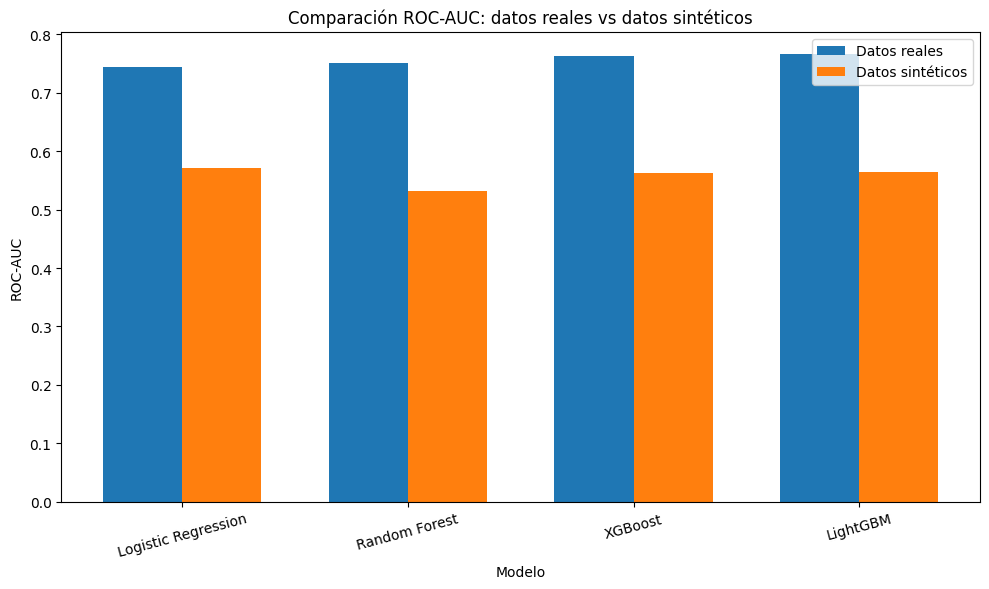

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

modelos = df_comparacion_baseline["Modelo"]

auc_real = df_comparacion_baseline["ROC-AUC_Real"]
auc_sintetico = df_comparacion_baseline["ROC-AUC_Sintético"]

x = np.arange(len(modelos))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    auc_real,
    width,
    label="Datos reales"
)

plt.bar(
    x + width/2,
    auc_sintetico,
    width,
    label="Datos sintéticos"
)

plt.xticks(x, modelos, rotation=15)
plt.ylabel("ROC-AUC")
plt.xlabel("Modelo")
plt.title("Comparación ROC-AUC: datos reales vs datos sintéticos")
plt.legend()
plt.tight_layout()
plt.show()

#### 4.8.4 Interpretación que debemos buscar

La interpretación no debe ser simplemente:

"Los modelos sintéticos obtuvieron peores resultados."

Hay que relacionarlo con lo que encontramos en las notebooks anteriores:

Gaussian Copula tuvo la mejor fidelidad estadística global, pero esa fidelidad no se trasladó completamente a la utilidad predictiva.

Por tanto, el resultado preliminar es:

La generación sintética consiguió preservar determinadas características estadísticas y estructurales del conjunto real, pero no consiguió preservar completamente la información predictiva asociada a la variable objetivo TARGET.

Y esto nos lleva directamente a nuestra siguiente etapa:

6.8 Comparación baseline
        ↓
6.9 Diagnóstico de pérdida de utilidad predictiva
        ↓
6.10 Optimización
        ↓
Modelos reales optimizados
        ↓
Modelos sintéticos optimizados
        ↓
Comparación final

Importante: no vamos a declarar todavía que Gaussian Copula es insuficiente. Primero debemos hacer el diagnóstico y posteriormente optimizar.

### 4.9 Diagnóstico de la pérdida de utilidad predictiva.

Aquí no vamos a optimizar todavía. Primero queremos responder por qué Gaussian Copula conserva razonablemente la estructura estadística, pero pierde tanta capacidad predictiva respecto a TARGET.

#### 4.9.1 Comparación de la relación entre variables y TARGET

La primera prueba será comparar la relación de cada variable numérica con TARGET entre:

df_real
df_gaussian (nuestro dataset sintético)

La idea es obtener algo como:

| Variable     | Asociación Real | Asociación Sintética | Diferencia |
| ------------ | --------------: | -------------------: | ---------: |
| EXT_SOURCE_1 |             ... |                  ... |        ... |
| EXT_SOURCE_2 |             ... |                  ... |        ... |
| EXT_SOURCE_3 |             ... |                  ... |        ... |
| AMT_CREDIT   |             ... |                  ... |        ... |
| ...          |             ... |                  ... |        ... |


In [ ]:
#Primero identificamos las variables numéricas comunes
# Variables numéricas comunes entre real y sintético
variables_numericas = df_real.select_dtypes(
    include=["number"]
).columns.intersection(
    df_sintetico.select_dtypes(include=["number"]).columns
)

# Eliminamos TARGET de las variables predictoras
variables_numericas = variables_numericas.drop(
    "TARGET",
    errors="ignore"
)

print("Número de variables numéricas:", len(variables_numericas))
print(variables_numericas.tolist())

Número de variables numéricas: 27
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'DAYS_EMPLOYED', 'OWN_CAR_AGE', 'HOUR_APPR_PROCESS_START', 'AGE', 'EMPLOYMENT_YEARS', 'HAS_CAR_AGE', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'INCOME_PER_FAMILY', 'CHILDREN_RATIO', 'CREDIT_TERM_EST']


In [ ]:
correlaciones_target = []

for variable in variables_numericas:

    corr_real = df_real[[variable, "TARGET"]].corr().iloc[0, 1]

    corr_sintetico = df_sintetico[[variable, "TARGET"]].corr().iloc[0, 1]

    correlaciones_target.append({
        "Variable": variable,
        "Correlación Real": corr_real,
        "Correlación Sintética": corr_sintetico,
        "Diferencia Absoluta": abs(
            corr_real - corr_sintetico
        )
    })

df_target_corr = pd.DataFrame(
    correlaciones_target
)

df_target_corr = df_target_corr.sort_values(
    "Diferencia Absoluta",
    ascending=False
)

df_target_corr.head(20)

,Variable,Correlación Real,Correlación Sintética,Diferencia Absoluta
10,EXT_SOURCE_2,-0.160294,-0.050987,0.109307
11,EXT_SOURCE_3,-0.155899,-0.047452,0.108447
9,EXT_SOURCE_1,-0.098887,-0.034437,0.064450
12,DAYS_BIRTH,0.078242,0.023980,0.054262
18,AGE,-0.078237,-0.023986,0.054251
23,CREDIT_GOODS_RATIO,0.068482,0.021662,0.046819
19,EMPLOYMENT_YEARS,-0.063336,-0.018671,0.044664
15,DAYS_EMPLOYED,0.063366,0.018707,0.044659
6,DEF_30_CNT_SOCIAL_CIRCLE,0.032408,-0.002688,0.035096
3,AMT_GOODS_PRICE,-0.039625,-0.006894,0.032730


#### 4.9.2 Una segunda comprobación: las variables más relacionadas con TARGET

In [ ]:
print("TOP variables según asociación con TARGET - REAL")

display(
    df_target_corr
    .sort_values(
        "Correlación Real",
        key=abs,
        ascending=False
    )
    .head(15)
)

TOP variables según asociación con TARGET - REAL


,Variable,Correlación Real,Correlación Sintética,Diferencia Absoluta
10,EXT_SOURCE_2,-0.160294,-0.050987,0.109307
11,EXT_SOURCE_3,-0.155899,-0.047452,0.108447
9,EXT_SOURCE_1,-0.098887,-0.034437,0.064450
12,DAYS_BIRTH,0.078242,0.023980,0.054262
18,AGE,-0.078237,-0.023986,0.054251
23,CREDIT_GOODS_RATIO,0.068482,0.021662,0.046819
15,DAYS_EMPLOYED,0.063366,0.018707,0.044659
19,EMPLOYMENT_YEARS,-0.063336,-0.018671,0.044664
3,AMT_GOODS_PRICE,-0.039625,-0.006894,0.032730
6,DEF_30_CNT_SOCIAL_CIRCLE,0.032408,-0.002688,0.035096


In [ ]:
print("TOP variables según asociación con TARGET - SINTÉTICO")

display(
    df_target_corr
    .assign(
        Abs_Corr_Sintetico=
        df_target_corr["Correlación Sintética"].abs()
    )
    .sort_values(
        "Abs_Corr_Sintetico",
        ascending=False
    )
    .head(15)
)

TOP variables según asociación con TARGET - SINTÉTICO


,Variable,Correlación Real,Correlación Sintética,Diferencia Absoluta,Abs_Corr_Sintetico
10,EXT_SOURCE_2,-0.160294,-0.050987,0.109307,0.050987
11,EXT_SOURCE_3,-0.155899,-0.047452,0.108447,0.047452
9,EXT_SOURCE_1,-0.098887,-0.034437,0.064450,0.034437
18,AGE,-0.078237,-0.023986,0.054251,0.023986
12,DAYS_BIRTH,0.078242,0.023980,0.054262,0.023980
23,CREDIT_GOODS_RATIO,0.068482,0.021662,0.046819,0.021662
15,DAYS_EMPLOYED,0.063366,0.018707,0.044659,0.018707
19,EMPLOYMENT_YEARS,-0.063336,-0.018671,0.044664,0.018671
26,CREDIT_TERM_EST,-0.032102,-0.007280,0.024822,0.007280
16,OWN_CAR_AGE,0.015981,0.007234,0.008748,0.007234


In [ ]:
#IMportancia de variables
import pandas as pd

# Importancia de variables - LightGBM REAL
importancia_lgbm_real = pd.DataFrame({
    "Variable": feature_names_lgbm_safe,
    "Importancia Real": lgbm_real.feature_importances_
})

# Importancia de variables - LightGBM SINTÉTICO
importancia_lgbm_synth = pd.DataFrame({
    "Variable": feature_names_lgbm_safe,
    "Importancia Sintética": modelo_lgbm_syn.feature_importances_
})

# Unir
comparacion_importancia = importancia_lgbm_real.merge(
    importancia_lgbm_synth,
    on="Variable"
)

# Diferencia absoluta
comparacion_importancia["Diferencia Absoluta"] = (
    comparacion_importancia["Importancia Real"] -
    comparacion_importancia["Importancia Sintética"]
).abs()

comparacion_importancia = comparacion_importancia.sort_values(
    "Importancia Real",
    ascending=False
)

comparacion_importancia.head(20)

,Variable,Importancia Real,Importancia Sintética,Diferencia Absoluta
149,remainder__CREDIT_TERM_EST,871,278,593
132,remainder__EXT_SOURCE_1,494,399,95
134,remainder__EXT_SOURCE_3,478,468,10
133,remainder__EXT_SOURCE_2,440,428,12
146,remainder__CREDIT_GOODS_RATIO,261,376,115
125,remainder__AMT_ANNUITY,241,215,26
135,remainder__DAYS_BIRTH,230,202,28
138,remainder__DAYS_EMPLOYED,226,252,26
145,remainder__ANNUITY_INCOME_RATIO,220,264,44
126,remainder__AMT_GOODS_PRICE,210,172,38
